<a href="https://colab.research.google.com/github/engineerchacon/Redes-Neuronales-Profundas/blob/main/Tarea_sobre_transferencia_de_aprendizaje_con_RNN_Armando_Chac%C3%B3n_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tarea sobre transferencia de aprendizaje con RNN-Armando Chacón Terrazas**

**Parte 1 – Reproducción del experimento base**

Descargar el archivo sentiment140-subset.csv y glove.6B.100d.txt   (https://nlp.stanford.edu/projects/glove/).
Ejecutar el código proporcionado (modelo A y modelo B).
Comparar los resultados de exactitud y pérdida en entrenamiento y validación.
Graficar las curvas accuracy y loss de ambos modelos.
Contestar:
¿Qué diferencias observas entre el entrenamiento desde cero y el uso de embeddings preentrenados?
¿Cuál converge más rápido?
¿Cuál generaliza mejor (mejor desempeño en validación)?

**Parte 2: Modificación de la arquitectura.**

Cambiar la arquitectura:
Reemplazar Bidirectional(LSTM(64)) por Bidirectional(GRU(64)) y comparar. Además, agregar una capa Dropout(0.5) después de la capa recurrente. Comparar resultados.
Evaluar con métricas adicionales:
Generar y analizar una matriz de confusión.
Calcular precisión, recall y F1-score.
Prueba con nuevas oraciones:
Crear un bloque de código para predecir el sentimiento de frases como:
"I really loved this trip!",

"This was a terrible experience.",

"My sister is afraid of going to the dentist.", etc.

# **Parte 1 – Reproducción del experimento base**

1. IMPORTAR LAS HERRAMIENTAS NECESARIAS

In [1]:
import numpy as np # Para manejar arreglos matemáticos
import pandas as pd # Para leer y manejar tablas de datos como Excel
import matplotlib.pyplot as plt # Para dibujar las gráficas al final
import tensorflow as tf # El motor principal de Inteligencia Artificial
from tensorflow import keras # Interfaz amigable para usar TensorFlow
from tensorflow.keras import layers # Para construir las "capas" de la red neuronal
from sklearn.model_selection import train_test_split # Para dividir nuestros datos en entrenamiento y prueba
from tensorflow.keras.preprocessing.text import Tokenizer # Para convertir texto a números
from tensorflow.keras.preprocessing.sequence import pad_sequences # Para que todas las frases tengan el mismo tamaño

2. CONECTAR GOOGLE DRIVE

In [2]:
# TensorFlow usará la GPU automáticamente si está disponible.
print("Verificando hardware...")
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"✅ ¡Excelente! GPU detectada y activada: {gpu_devices[0].name}")
else:
    print("⚠️ ALERTA: No se detectó ninguna GPU.")
    print("Para que el entrenamiento sea rápido, ve al menú superior: 'Entorno de ejecución' -> 'Cambiar tipo de entorno de ejecución' -> Selecciona 'T4 GPU' y guarda.")

from google.colab import drive
drive.mount('/content/drive')

# Rutas de los archivos en variables
ruta_csv = "/content/drive/MyDrive/UACJ/Redes Neuronales Profundas/Colab_Datasets/Tarea sobre transferencia de aprendizaje con RNN/sentiment140-subset.csv"
ruta_glove = "/content/drive/MyDrive/UACJ/Redes Neuronales Profundas/Colab_Datasets/Tarea sobre transferencia de aprendizaje con RNN/glove.6B.100d.txt"

Verificando hardware...
✅ ¡Excelente! GPU detectada y activada: /physical_device:GPU:0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


3. CARGAR LOS DATOS (El archivo CSV)

In [3]:
# Leemos el archivo CSV.
df = pd.read_csv(ruta_csv)

# Extraemos los textos y las etiquetas (0 = negativo, 1 = positivo)
texts = df["text"].astype(str).values
labels = df["polarity"].values

4. TOKENIZACIÓN (Convertir palabras a números)

In [4]:
# Las redes neuronales no entienden palabras, solo números.
VOCAB_SIZE = 10000 # Solo aprenderemos las 10,000 palabras más comunes del dataset.
MAX_LEN = 40       # Cortaremos o rellenaremos las oraciones para que todas tengan exactamente 40 palabras.

# Creamos el tokenizador y le enseñamos nuestros textos
tokenizer = Tokenizer(num_words=VOCAB_SIZE, filters='!"$%&()*+,-./:;<=>?[\\]^_`{|}~\t\n')
tokenizer.fit_on_texts(texts) # Construye un vocabulario y asigna a cada palabra un índice entero.

# Transformamos las oraciones de texto a listas de números
X = tokenizer.texts_to_sequences(texts)
# Rellenamos con ceros (al final de la frase) si la oración tiene menos de 40 palabras
X = pad_sequences(X, maxlen=MAX_LEN, padding="post")
y = np.array(labels)

# Dividimos los datos: 85% para que la red estudie (entrenamiento) y 15% para hacerle un examen (validación)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)
print("¡Datos listos para entrenar!")

¡Datos listos para entrenar!


5. MODELO A - EMBEDDING DESDE CERO

In [5]:
# La red aprenderá el significado de las palabras desde cero, ajustando sus propios vectores.
print("\n--- INICIANDO MODELO A (Desde cero) ---")
embed_dim = 100 # Cada palabra se representará con una lista de 100 números

model_a = keras.Sequential([
    layers.Input(shape=(X.shape[1],), dtype='int32'),
    # La capa Embedding inicializa vectores al azar y los aprende con el tiempo
    layers.Embedding(VOCAB_SIZE, embed_dim, input_length = MAX_LEN),
    layers.Bidirectional(layers.LSTM(64)), # Capa que lee la frase de izquierda a derecha y viceversa
    layers.Dense(1, activation="sigmoid") # Decisión final: ¿Es 0 (negativo) o 1 (positivo)?
])

model_a.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Nota: Se cambio "epochs" de 100 a 20 para que no tarde horas en Colab
hist_a = model_a.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=20, batch_size=64, verbose=2)


--- INICIANDO MODELO A (Desde cero) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
6641/6641 - 66s - 10ms/step - accuracy: 0.7949 - loss: 0.4391 - val_accuracy: 0.8092 - val_loss: 0.4151
Epoch 2/20
6641/6641 - 59s - 9ms/step - accuracy: 0.8228 - loss: 0.3906 - val_accuracy: 0.8132 - val_loss: 0.4084
Epoch 3/20
6641/6641 - 60s - 9ms/step - accuracy: 0.8358 - loss: 0.3652 - val_accuracy: 0.8148 - val_loss: 0.4104
Epoch 4/20
6641/6641 - 64s - 10ms/step - accuracy: 0.8491 - loss: 0.3403 - val_accuracy: 0.8134 - val_loss: 0.4220
Epoch 5/20
6641/6641 - 60s - 9ms/step - accuracy: 0.8624 - loss: 0.3139 - val_accuracy: 0.8094 - val_loss: 0.4390
Epoch 6/20
6641/6641 - 82s - 12ms/step - accuracy: 0.8757 - loss: 0.2876 - val_accuracy: 0.8064 - val_loss: 0.4689
Epoch 7/20
6641/6641 - 60s - 9ms/step - accuracy: 0.8889 - loss: 0.2604 - val_accuracy: 0.7991 - val_loss: 0.4951
Epoch 8/20
6641/6641 - 82s - 12ms/step - accuracy: 0.9008 - loss: 0.2341 - val_accuracy: 0.7984 - val_loss: 0.5518
Epoch 9/20
6641/6641 - 59s - 9ms/step - accuracy: 0.9125 - loss: 0.2094 - val_accura

6. MODELO B - EMBEDDING PREENTRENADO (GLOVE)

In [6]:
# Usamos el conocimiento previo. Ya que GloVe ya leyó millones de textos en internet.
print("\n--- INICIANDO MODELO B (GloVe) ---")
print("Cargando el archivo GloVe")

# Leemos el archivo GloVe línea por línea para sacar la palabra y sus 100 números.
embeddings_index = {}
with open(ruta_glove, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

# Construimos una matriz (tabla) especial para nuestro vocabulario de 10,000 palabras.
embedding_matrix = np.zeros((VOCAB_SIZE, 100))
for word, i in tokenizer.word_index.items():
    if i < VOCAB_SIZE:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec # Si la palabra existe en GloVe, guardamos su vector.

# Construimos el Modelo B
model_b = keras.Sequential([
    layers.Input(shape=(X.shape[1],), dtype='int32'),
    # Usamos la matriz que acabamos de crear (weights=[embedding_matrix]).
    # trainable=False significa que esos embeddings se quedan congelados durante el entrenamiento.
    layers.Embedding(VOCAB_SIZE, 100, input_length=MAX_LEN,
                     weights=[embedding_matrix],
                     trainable=False),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(1, activation="sigmoid")
])

model_b.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_b = model_b.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=20, batch_size=64, verbose=2)


--- INICIANDO MODELO B (GloVe) ---
Cargando el archivo GloVe
Epoch 1/20
6641/6641 - 61s - 9ms/step - accuracy: 0.7555 - loss: 0.4972 - val_accuracy: 0.7758 - val_loss: 0.4668
Epoch 2/20
6641/6641 - 59s - 9ms/step - accuracy: 0.7889 - loss: 0.4473 - val_accuracy: 0.7913 - val_loss: 0.4464
Epoch 3/20
6641/6641 - 58s - 9ms/step - accuracy: 0.7999 - loss: 0.4287 - val_accuracy: 0.7863 - val_loss: 0.4513
Epoch 4/20
6641/6641 - 59s - 9ms/step - accuracy: 0.8072 - loss: 0.4164 - val_accuracy: 0.7990 - val_loss: 0.4328
Epoch 5/20
6641/6641 - 86s - 13ms/step - accuracy: 0.8131 - loss: 0.4064 - val_accuracy: 0.7978 - val_loss: 0.4355
Epoch 6/20
6641/6641 - 77s - 12ms/step - accuracy: 0.8176 - loss: 0.3985 - val_accuracy: 0.7996 - val_loss: 0.4298
Epoch 7/20
6641/6641 - 58s - 9ms/step - accuracy: 0.8214 - loss: 0.3912 - val_accuracy: 0.8029 - val_loss: 0.4311
Epoch 8/20
6641/6641 - 58s - 9ms/step - accuracy: 0.8248 - loss: 0.3845 - val_accuracy: 0.8015 - val_loss: 0.4309
Epoch 9/20
6641/6641 - 5

7. GRAFICAR RESULTADOS (Comparativa)


--- GENERANDO GRÁFICAS ---


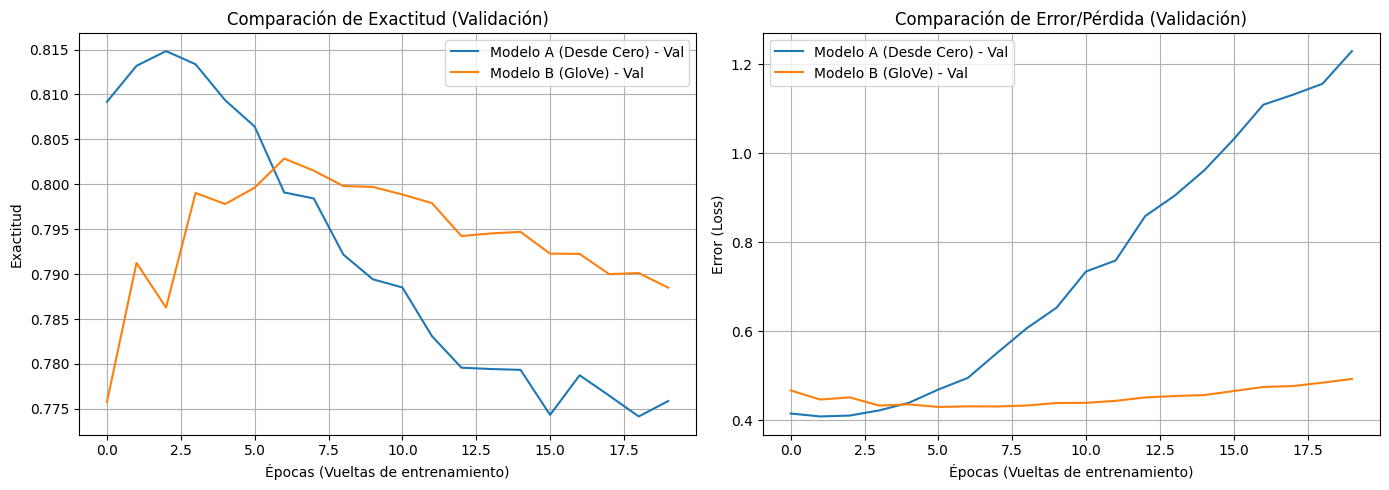

In [7]:
print("\n--- GENERANDO GRÁFICAS ---")

# Creamos un lienzo para dibujar dos gráficas (Exactitud y Pérdida)
plt.figure(figsize=(14, 5))

# Gráfica 1: Exactitud (Accuracy) -> (Entre más alto, mejor)
plt.subplot(1, 2, 1)
plt.plot(hist_a.history['val_accuracy'], label='Modelo A (Desde Cero) - Val')
plt.plot(hist_b.history['val_accuracy'], label='Modelo B (GloVe) - Val')
plt.title('Comparación de Exactitud (Validación)')
plt.xlabel('Épocas (Vueltas de entrenamiento)')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True)

# Gráfica 2: Pérdida (Loss) -> (Entre más bajo, mejor)
plt.subplot(1, 2, 2)
plt.plot(hist_a.history['val_loss'], label='Modelo A (Desde Cero) - Val')
plt.plot(hist_b.history['val_loss'], label='Modelo B (GloVe) - Val')
plt.title('Comparación de Error/Pérdida (Validación)')
plt.xlabel('Épocas (Vueltas de entrenamiento)')
plt.ylabel('Error (Loss)')
plt.legend()
plt.grid(True)

# Mostramos la gráfica en pantalla
plt.tight_layout()
plt.show()

**1. ¿Qué diferencias observas entre el entrenamiento desde cero y el uso de embeddings preentrenados?**

La principal diferencia se observa en la estabilidad del margen de error. En el Modelo A (entrenado desde cero), el error comienza a subir rápidamente después de la tercera época. Esto nos indica que el modelo está memorizando los datos de entrenamiento en lugar de aprender a interpretarlos, ya que los identificadores básicos de las palabras no contienen información semántica por sí solos. Por otro lado, el Modelo B (con GloVe) muestra un comportamiento mucho más estable y controlado. Esto se debe a que utiliza representaciones numéricas que ya contienen información útil para distinguir relaciones y similitudes entre las palabras desde antes de empezar.

**2. ¿Cuál converge más rápido?**

El Modelo B logra estabilizarse de manera más efectiva. Aunque el Modelo A parece subir su nivel de exactitud muy rápido en las primeras dos épocas, en realidad es un incremento engañoso porque poco después pierde su capacidad de predicción. El Modelo B, en cambio, encuentra un punto de equilibrio sólido alrededor de la época 6 y se mantiene constante. Como las representaciones de las palabras ya están definidas, el sistema no pierde tiempo tratando de entender el idioma y se enfoca directamente en analizar el sentimiento de los textos.

**3. ¿Cuál generaliza mejor (mejor desempeño en validación)?**

El Modelo B tiene una capacidad claramente superior para generalizar frente a datos desconocidos. Al final de las 20 épocas, este modelo conserva una exactitud cercana al 79%, mientras que el Modelo A desciende al 77.5% mostrando una tendencia a seguir empeorando. La ventaja del Modelo B radica en que su base de conocimiento previo permite que palabras con significados o usos parecidos tengan representaciones similares, ayudando a interpretar correctamente frases nuevas. En conclusión, el Modelo B es superior porque aprovecha ese respaldo lingüístico para no depender exclusivamente de la información limitada de nuestro conjunto de datos.

# **Parte 2: Modificación de la arquitectura.**

**Cambiar la arquitectura:**

8. REEMPLAZAR LSTM POR GRU

In [8]:
# Construimos el modelo exactamente igual, pero cambiamos LSTM por GRU
model_c = keras.Sequential([
    layers.Input(shape=(X.shape[1],), dtype='int32'),
    layers.Embedding(VOCAB_SIZE, 100, input_length=MAX_LEN,
                     weights=[embedding_matrix],
                     trainable=False),  # Mantenemos GloVe congelado
    layers.Bidirectional(layers.GRU(64)), # <--- Usamos GRU
    layers.Dense(1, activation="sigmoid")
])

model_c.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Lo ponemos a entrenar
hist_c = model_c.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=20, batch_size=64, verbose=2)

Epoch 1/20
6641/6641 - 66s - 10ms/step - accuracy: 0.7601 - loss: 0.4923 - val_accuracy: 0.7825 - val_loss: 0.4618
Epoch 2/20
6641/6641 - 75s - 11ms/step - accuracy: 0.7910 - loss: 0.4456 - val_accuracy: 0.7917 - val_loss: 0.4442
Epoch 3/20
6641/6641 - 57s - 9ms/step - accuracy: 0.8006 - loss: 0.4288 - val_accuracy: 0.7971 - val_loss: 0.4369
Epoch 4/20
6641/6641 - 83s - 12ms/step - accuracy: 0.8076 - loss: 0.4175 - val_accuracy: 0.8000 - val_loss: 0.4333
Epoch 5/20
6641/6641 - 63s - 9ms/step - accuracy: 0.8116 - loss: 0.4093 - val_accuracy: 0.7983 - val_loss: 0.4335
Epoch 6/20
6641/6641 - 61s - 9ms/step - accuracy: 0.8159 - loss: 0.4020 - val_accuracy: 0.8008 - val_loss: 0.4328
Epoch 7/20
6641/6641 - 60s - 9ms/step - accuracy: 0.8192 - loss: 0.3955 - val_accuracy: 0.8001 - val_loss: 0.4337
Epoch 8/20
6641/6641 - 57s - 9ms/step - accuracy: 0.8217 - loss: 0.3915 - val_accuracy: 0.7963 - val_loss: 0.4406
Epoch 9/20
6641/6641 - 57s - 9ms/step - accuracy: 0.8262 - loss: 0.3840 - val_accurac

Las capas GRU son como las hermanas menores y más rápidas de las LSTM. Hacen casi lo mismo (recordar el contexto de la frase), pero con menos operaciones matemáticas.

# COMPARATIVA TÉCNICA FINAL: MODELO B (LSTM) VS MODELO C (GRU)

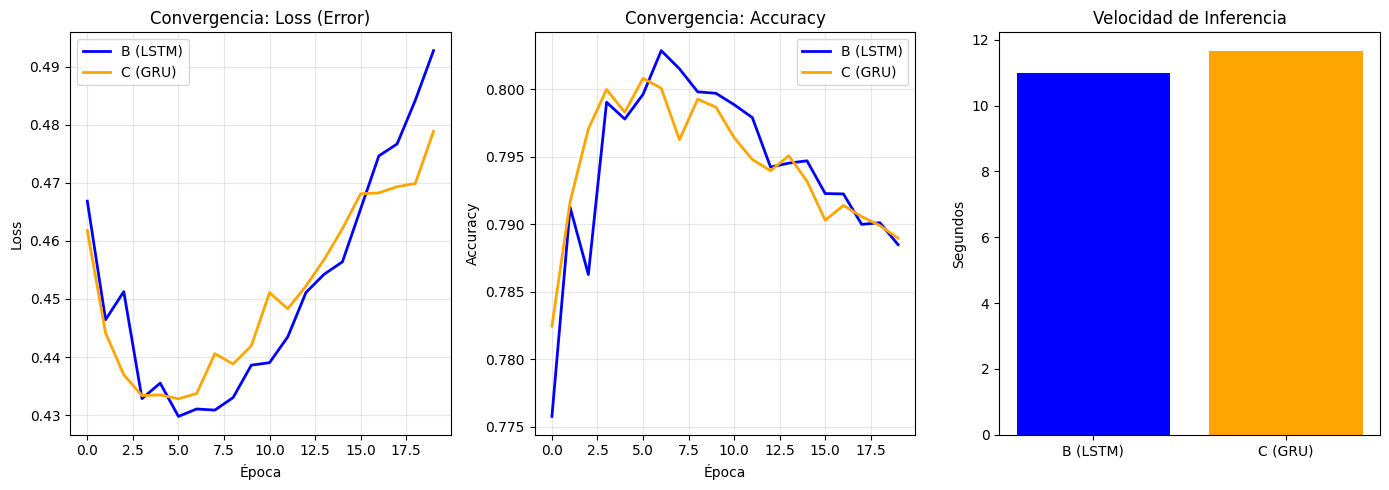


                 REPORTE DE COMPARACIÓN
              Métrica Modelo B (LSTM) Modelo C (GRU)
     Total Parámetros       1,084,609      1,063,873
    Loss (Validación)          0.4928         0.4789
Accuracy (Validación)          0.7885         0.7890
Tiempo Inferencia (s)         10.9956        11.6414


In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import time

def generar_comparativa(mod_b, mod_c, historial_b, historial_c, datos_x, datos_y):
    # 1. Conteo de parámetros (Complejidad)
    params_b = mod_b.count_params()
    params_c = mod_c.count_params()

    # 2. Evaluación de rendimiento (Loss y Accuracy) y Tiempo
    start = time.time()
    score_b = mod_b.evaluate(datos_x, datos_y, verbose=0)
    time_b = time.time() - start

    start = time.time()
    score_c = mod_c.evaluate(datos_x, datos_y, verbose=0)
    time_c = time.time() - start

    # Nota: Keras devuelve una lista si hay más de una métrica (ej. loss y accuracy)
    loss_b = score_b[0] if isinstance(score_b, list) else score_b
    loss_c = score_c[0] if isinstance(score_c, list) else score_c

    acc_b = score_b[1] if isinstance(score_b, list) and len(score_b) > 1 else "N/A"
    acc_c = score_c[1] if isinstance(score_c, list) and len(score_c) > 1 else "N/A"

    # 3. Creación de la tabla de resultados
    datos = {
        'Métrica': ['Total Parámetros', 'Loss (Validación)', 'Accuracy (Validación)', 'Tiempo Inferencia (s)'],
        'Modelo B (LSTM)': [f"{params_b:,}", f"{loss_b:.4f}", f"{acc_b:.4f}" if acc_b != "N/A" else acc_b, f"{time_b:.4f}"],
        'Modelo C (GRU)': [f"{params_c:,}", f"{loss_c:.4f}", f"{acc_c:.4f}" if acc_c != "N/A" else acc_c, f"{time_c:.4f}"]
    }
    df = pd.DataFrame(datos)

    # 4. Gráficas de convergencia y tiempos
    plt.figure(figsize=(14, 5))

    # Gráfica de Loss
    plt.subplot(1, 3, 1)
    plt.plot(historial_b.history['val_loss'], label='B (LSTM)', color='blue', linewidth=2)
    plt.plot(historial_c.history['val_loss'], label='C (GRU)', color='orange', linewidth=2)
    plt.title('Convergencia: Loss (Error)')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Gráfica de Accuracy (si existe)
    plt.subplot(1, 3, 2)
    if 'val_accuracy' in historial_b.history:
        plt.plot(historial_b.history['val_accuracy'], label='B (LSTM)', color='blue', linewidth=2)
        plt.plot(historial_c.history['val_accuracy'], label='C (GRU)', color='orange', linewidth=2)
        plt.title('Convergencia: Accuracy')
        plt.xlabel('Época')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Accuracy no disponible', ha='center', va='center')
        plt.title('Convergencia: Accuracy')

    # Gráfica de Tiempos
    plt.subplot(1, 3, 3)
    plt.bar(['B (LSTM)', 'C (GRU)'], [time_b, time_c], color=['blue', 'orange'])
    plt.title('Velocidad de Inferencia')
    plt.ylabel('Segundos')

    plt.tight_layout()
    plt.show()

    # 5. Imprimir reporte en texto
    print("\n" + "="*55)
    print("                 REPORTE DE COMPARACIÓN")
    print("="*55)
    print(df.to_string(index=False))
    print("="*55)

# EJECUCIÓN CON LAS VARIABLES EXACTAS DE TU CÓDIGO:
generar_comparativa(model_b, model_c, hist_b, hist_c, X_val, y_val)

9. AGREGANDO DROPOUT (0.5) AL MODELO GRU

In [9]:
#  AGREGANDO DROPOUT (0.5) AL MODELO GRU
model_d = keras.Sequential([
    layers.Input(shape=(X.shape[1],), dtype='int32'),
    layers.Embedding(VOCAB_SIZE, 100, input_length=MAX_LEN,
                     weights=[embedding_matrix],
                     trainable=False),
    layers.Bidirectional(layers.GRU(64)), # <--- Mantenemos el GRU de la actividad 8
    layers.Dropout(0.5), # <--- Agregamos el Dropout para apagar neuronas al azar y evitar overfitting
    layers.Dense(1, activation="sigmoid")
])

model_d.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_d = model_d.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=20, batch_size=64, verbose=2)

Epoch 1/20
6641/6641 - 62s - 9ms/step - accuracy: 0.7513 - loss: 0.5067 - val_accuracy: 0.7764 - val_loss: 0.4705
Epoch 2/20
6641/6641 - 60s - 9ms/step - accuracy: 0.7816 - loss: 0.4627 - val_accuracy: 0.7866 - val_loss: 0.4531
Epoch 3/20
6641/6641 - 59s - 9ms/step - accuracy: 0.7905 - loss: 0.4478 - val_accuracy: 0.7932 - val_loss: 0.4448
Epoch 4/20
6641/6641 - 81s - 12ms/step - accuracy: 0.7963 - loss: 0.4387 - val_accuracy: 0.7953 - val_loss: 0.4408
Epoch 5/20
6641/6641 - 59s - 9ms/step - accuracy: 0.8009 - loss: 0.4312 - val_accuracy: 0.7968 - val_loss: 0.4363
Epoch 6/20
6641/6641 - 59s - 9ms/step - accuracy: 0.8048 - loss: 0.4247 - val_accuracy: 0.7962 - val_loss: 0.4376
Epoch 7/20
6641/6641 - 61s - 9ms/step - accuracy: 0.8082 - loss: 0.4193 - val_accuracy: 0.7979 - val_loss: 0.4357
Epoch 8/20
6641/6641 - 59s - 9ms/step - accuracy: 0.8107 - loss: 0.4147 - val_accuracy: 0.7967 - val_loss: 0.4365
Epoch 9/20
6641/6641 - 58s - 9ms/step - accuracy: 0.8137 - loss: 0.4094 - val_accuracy:

# COMPARATIVA TÉCNICA FINAL: MODELO C (GRU) VS MODELO D (GRU CON DROPOUT)

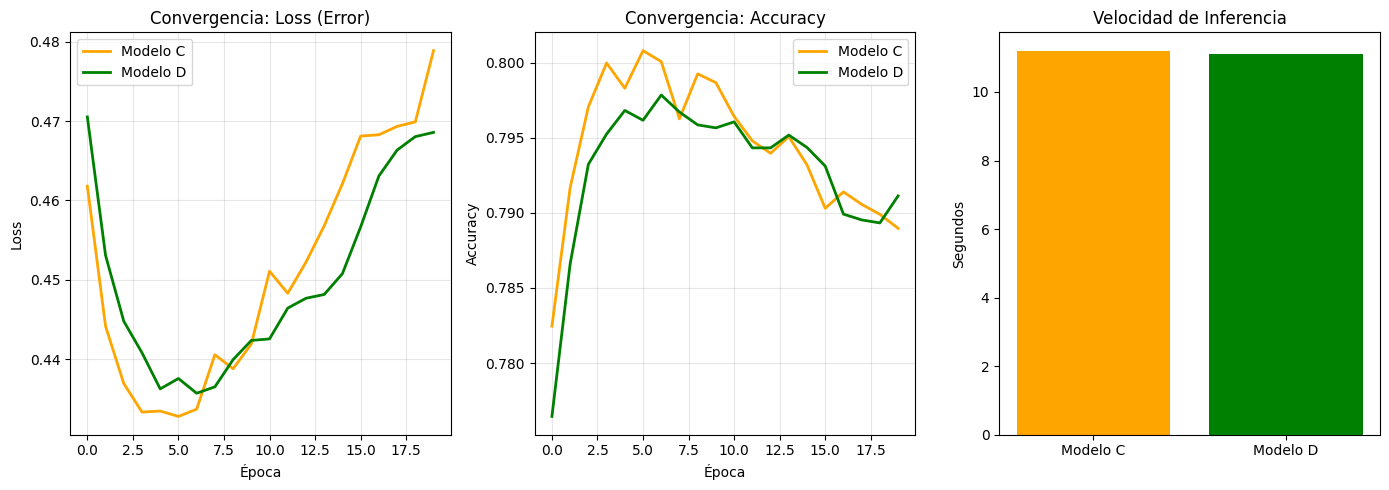


                 REPORTE DE COMPARACIÓN C vs D
              Métrica  Modelo C  Modelo D
     Total Parámetros 1,063,873 1,063,873
    Loss (Validación)    0.4789    0.4686
Accuracy (Validación)    0.7890    0.7911
Tiempo Inferencia (s)   11.1817   11.1227


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import time

def generar_comparativa_cd(mod_c, mod_d, historial_c, historial_d, datos_x, datos_y):
    # Sacamos cuántos parámetros tiene cada uno para ver cuál es más pesado
    params_c = mod_c.count_params()
    params_d = mod_d.count_params()

    # Medimos el tiempo y sacamos el score (Loss y Accuracy si lo tiene)
    start = time.time()
    score_c = mod_c.evaluate(datos_x, datos_y, verbose=0)
    time_c = time.time() - start

    start = time.time()
    score_d = mod_d.evaluate(datos_x, datos_y, verbose=0)
    time_d = time.time() - start

    # Acomodamos los resultados por si solo hay Loss o también Accuracy
    loss_c = score_c[0] if isinstance(score_c, list) else score_c
    loss_d = score_d[0] if isinstance(score_d, list) else score_d

    acc_c = score_c[1] if isinstance(score_c, list) and len(score_c) > 1 else "N/A"
    acc_d = score_d[1] if isinstance(score_d, list) and len(score_d) > 1 else "N/A"

    # Armamos la tabla
    datos = {
        'Métrica': ['Total Parámetros', 'Loss (Validación)', 'Accuracy (Validación)', 'Tiempo Inferencia (s)'],
        'Modelo C': [f"{params_c:,}", f"{loss_c:.4f}", f"{acc_c:.4f}" if acc_c != "N/A" else acc_c, f"{time_c:.4f}"],
        'Modelo D': [f"{params_d:,}", f"{loss_d:.4f}", f"{acc_d:.4f}" if acc_d != "N/A" else acc_d, f"{time_d:.4f}"]
    }
    df = pd.DataFrame(datos)

    # Dibujamos las gráficas
    plt.figure(figsize=(14, 5))

    # 1. Gráfica de Loss
    plt.subplot(1, 3, 1)
    plt.plot(historial_c.history['val_loss'], label='Modelo C', color='orange', linewidth=2)
    plt.plot(historial_d.history['val_loss'], label='Modelo D', color='green', linewidth=2)
    plt.title('Convergencia: Loss (Error)')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 2. Gráfica de Accuracy (si está en el historial)
    plt.subplot(1, 3, 2)
    if 'val_accuracy' in historial_c.history and 'val_accuracy' in historial_d.history:
        plt.plot(historial_c.history['val_accuracy'], label='Modelo C', color='orange', linewidth=2)
        plt.plot(historial_d.history['val_accuracy'], label='Modelo D', color='green', linewidth=2)
        plt.title('Convergencia: Accuracy')
        plt.xlabel('Época')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Accuracy no graficable', ha='center', va='center')
        plt.title('Convergencia: Accuracy')

    # 3. Gráfica de Tiempos
    plt.subplot(1, 3, 3)
    plt.bar(['Modelo C', 'Modelo D'], [time_c, time_d], color=['orange', 'green'])
    plt.title('Velocidad de Inferencia')
    plt.ylabel('Segundos')

    plt.tight_layout()
    plt.show()

    # Imprimimos la tabla perrona
    print("\n" + "="*55)
    print("                 REPORTE DE COMPARACIÓN C vs D")
    print("="*55)
    print(df.to_string(index=False))
    print("="*55)

# Corremos la función con tus variables
generar_comparativa_cd(model_c, model_d, hist_c, hist_d, X_val, y_val)

**Evaluar con métricas adicionales:**

10. MATRIZ DE CONFUSIÓN Y MÉTRICAS (Basado en Modelo GRU con droput 0.5)


--- GENERANDO REPORTE DE EVALUACIÓN PARA Modelo GRU con droput 0.5 ---
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


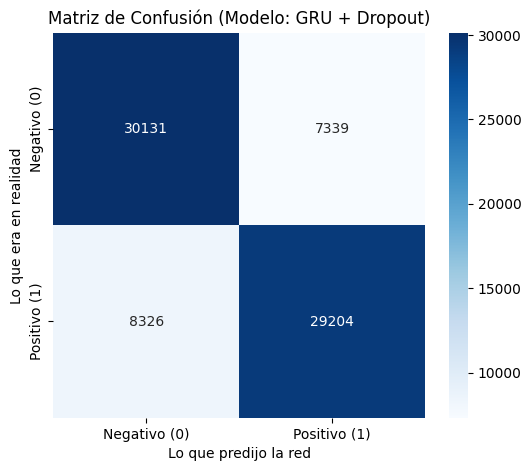


--- REPORTE DE CLASIFICACIÓN (Modelo GRU con droput 0.5) ---
              precision    recall  f1-score   support

Negativo (0)       0.78      0.80      0.79     37470
Positivo (1)       0.80      0.78      0.79     37530

    accuracy                           0.79     75000
   macro avg       0.79      0.79      0.79     75000
weighted avg       0.79      0.79      0.79     75000



In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("\n--- GENERANDO REPORTE DE EVALUACIÓN PARA Modelo GRU con droput 0.5 ---")

# 1. Hacemos que el Modelo prediga los datos del examen (validación)
# Nos dará probabilidades (ej. 0.85). Todo lo mayor a 0.5 lo consideramos Positivo (1).
y_pred_prob = model_d.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. Creamos la Matriz de Confusión
cm = confusion_matrix(y_val, y_pred)

# La dibujamos bien con seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo (0)', 'Positivo (1)'],
            yticklabels=['Negativo (0)', 'Positivo (1)'])
plt.title('Matriz de Confusión (Modelo: GRU + Dropout)')
plt.xlabel('Lo que predijo la red')
plt.ylabel('Lo que era en realidad')
plt.show()

# 3. Calculamos Precision, Recall y F1-Score
print("\n--- REPORTE DE CLASIFICACIÓN (Modelo GRU con droput 0.5) ---")
print(classification_report(y_val, y_pred, target_names=['Negativo (0)', 'Positivo (1)']))

**Prueba con nuevas oraciones:**

11. PREDICCIÓN DE FRASES NUEVAS

In [13]:
# Aquí están 3 frases
nuevas_frases = [
    "i miss my friends bad",        # Frase a
    "Alright. Off to bed",          # Frase b
    "I am way tired, too much work." # Frase c
]

print("--- ANALIZANDO NUEVAS FRASES CON Modelo GRU con droput 0.5 ---\n")

# Paso A: Convertir el texto a números usando el mismo diccionario que ya aprendió el Tokenizer
secuencias_nuevas = tokenizer.texts_to_sequences(nuevas_frases)

# Paso B: Rellenar con ceros para que midan exactamente 40 tokens (MAX_LEN)
secuencias_pad = pad_sequences(secuencias_nuevas, maxlen=MAX_LEN, padding="post")

# Paso C: Predecir el sentimiento (Usando el Modelo con GRU y Dropout)
predicciones = model_d.predict(secuencias_pad)

# Paso D: Mostrar los resultados de forma amigable
for i, frase in enumerate(nuevas_frases):
    probabilidad = predicciones[i][0]

    # Si la probabilidad es mayor a 0.5, es positivo. Si no, es negativo.
    if probabilidad > 0.5:
        sentimiento = "POSITIVO 😃"
    else:
        sentimiento = "NEGATIVO 😞"

    print(f"Frase: '{frase}'")
    print(f"Puntaje de la red: {probabilidad:.4f} -> El sentimiento es {sentimiento}")
    print("-" * 50)

--- ANALIZANDO NUEVAS FRASES CON Modelo GRU con droput 0.5 ---

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Frase: 'i miss my friends bad'
Puntaje de la red: 0.0146 -> El sentimiento es NEGATIVO 😞
--------------------------------------------------
Frase: 'Alright. Off to bed'
Puntaje de la red: 0.9029 -> El sentimiento es POSITIVO 😃
--------------------------------------------------
Frase: 'I am way tired, too much work.'
Puntaje de la red: 0.0206 -> El sentimiento es NEGATIVO 😞
--------------------------------------------------
